# MFE 230X — Homework 3

**Matthieu Pascal**
**Hidden liquidity replication**

This notebook is the single working document for Part 1 of the assignment. It:

1. reproduces Table 2 of Avellaneda, Reed, and Stoikov (2011) and compares it with the published values;
2. estimates the empirical and model probabilities of Table 3 on Nasdaq, including AAPL conditional on the spread;
3. reports the bid/ask-size deciles and the fitted hidden-liquidity parameter $H$, compared with Table 4 of the paper;
4. documents how $H$ depends on estimation conventions and how precisely it is estimated.

The assignment says to choose four securities out of five, while the supplied TAQ file contains the four securities used in the paper: **XLF, QQQQ, JPM, and AAPL**. Therefore all four available securities are analyzed. The TAQ sample is January 4–8, 2010, from 10:00 a.m. to 4:00 p.m.

## 1. Data and empirical design

The source is the supplied WRDS TAQ quote file `data.csv`. I retain only regular common-stock symbols (`SYM_SUFFIX` blank), valid quotes (`BID > 0`, `ASK > BID`), and the three venues in the article:

- **T**: Nasdaq
- **P**: NYSE Arca (labelled "NYSE" in the paper's Tables 2 and 4)
- **Z**: BATS

Table 2 uses all three venues. Table 3 uses Nasdaq only. Table 2's quotes-per-second denominator is
$5\text{ days}\times6\text{ hours}\times3600=108{,}000$ seconds.

For a quote at time $t$, the Table 3 outcome is one if the **next nonzero Nasdaq midquote change** (same day) is upward and zero if it is downward. The corrected model probability (eq. 13–14, with the "2" in the denominator that Table 3's caption omits) is

$$
P(\text{up}\mid i,j)=\frac{i+H}{i+j+2H},
$$

where $i$ and $j$ are the bid- and ask-size decile labels. Section 3 states every convention behind the estimate of $H$.

In [1]:
import os
from pathlib import Path
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.optimize import curve_fit, minimize_scalar

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

HW3_DIR = Path.cwd()
OUTPUT_DIR = HW3_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# data.csv is looked up in $HW3_DATA, then in HW3/, then in the sibling folder 'Data WRDS/'.
DATA_CANDIDATES = [
    Path(os.environ["HW3_DATA"]) if "HW3_DATA" in os.environ else None,
    HW3_DIR / "data.csv",
    HW3_DIR.parent / "Data WRDS" / "data.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p is not None and p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Set HW3_DATA, or place data.csv either in HW3/ or in the sibling folder 'Data WRDS/'."
    )

TICKERS = ["XLF", "QQQQ", "JPM", "AAPL"]
EXCHANGES = ["P", "T", "Z"]
SECONDS_IN_SAMPLE = 5 * 6 * 60 * 60

print(f"Data: {DATA_PATH.name} (in {DATA_PATH.parent.name}/)")
print(f"Outputs: {OUTPUT_DIR.relative_to(HW3_DIR)}/")

Data: data.csv (in Data WRDS/)
Outputs: outputs/


In [2]:
# DuckDB scans the large CSV without first loading the full file into RAM.
con = duckdb.connect()
csv_path_sql = str(DATA_PATH).replace("'", "''")
con.execute(f"""
    CREATE OR REPLACE VIEW quotes AS
    SELECT row_number() OVER () AS source_row, *
    FROM read_csv_auto('{csv_path_sql}', header=True, sample_size=-1)
""")

audit = con.execute("""
    SELECT
        count(*) AS raw_rows,
        min(DATE) AS first_date,
        max(DATE) AS last_date,
        min(TIME_M) AS first_time,
        max(TIME_M) AS last_time,
        count(DISTINCT SYM_ROOT) AS ticker_count,
        string_agg(DISTINCT SYM_ROOT, ', ' ORDER BY SYM_ROOT) AS tickers
    FROM quotes
""").df()
display(audit)

,raw_rows,first_date,last_date,first_time,last_time,ticker_count,tickers
0,20485503,20100104,20100108,10:00:00,16:00:00,4,"AAPL, JPM, QQQQ, XLF"


## 2. Replication of Table 2

For every security–venue pair, the table reports the number of quote updates, updates per second, average quoted spread, average displayed depth (`BIDSIZ + ASKSIZ`), and average midquote. TAQ sizes are in round lots, consistent with the article.

In [3]:
table2 = con.execute(f"""
    SELECT
        SYM_ROOT AS ticker,
        EX AS exchange,
        count(*) AS num_quotes,
        count(*) / {SECONDS_IN_SAMPLE}.0 AS quotes_per_second,
        avg(ASK - BID) AS avg_spread,
        avg(BIDSIZ + ASKSIZ) AS avg_total_depth,
        avg((BID + ASK) / 2.0) AS avg_midprice
    FROM quotes
    WHERE coalesce(SYM_SUFFIX, '') = ''
      AND BID > 0
      AND ASK > BID
      AND SYM_ROOT IN ('XLF', 'QQQQ', 'JPM', 'AAPL')
      AND EX IN ('P', 'T', 'Z')
    GROUP BY SYM_ROOT, EX
    ORDER BY CASE SYM_ROOT
        WHEN 'XLF' THEN 1 WHEN 'QQQQ' THEN 2 WHEN 'JPM' THEN 3 ELSE 4 END,
        EX
""").df()

table2.to_csv(OUTPUT_DIR / "table2_replication.csv", index=False)
display(Markdown("**Table 2 replication**"))
display(table2.round({
    "quotes_per_second": 2,
    "avg_spread": 4,
    "avg_total_depth": 3,
    "avg_midprice": 4,
}))

**Table 2 replication**

,ticker,exchange,num_quotes,quotes_per_second,avg_spread,avg_total_depth,avg_midprice
0,XLF,P,444796,4.1200,0.0102,"10,466.7590",15.0104
1,XLF,T,720846,6.6700,0.0102,"8,799.5290",15.0177
2,XLF,Z,426226,3.9500,0.0107,"7,507.8480",14.9967
3,QQQQ,P,3961631,36.6800,0.0114,"1,151.9090",46.2696
4,QQQQ,T,2713897,25.1300,0.0103,"1,455.2150",46.2951
5,QQQQ,Z,1635915,15.1500,0.0113,"1,055.3960",46.2826
6,JPM,P,689936,6.3900,0.0120,46.6070,43.7714
7,JPM,T,1179830,10.9200,0.0113,86.7690,43.8102
8,JPM,Z,579148,5.3600,0.0142,38.8350,43.8280
9,AAPL,P,413263,3.8300,0.0462,5.7290,212.6599


In [4]:
# Published Table 2 (the paper's "NYSE" rows are venue P = NYSE Arca).
paper_table2 = pd.DataFrame(
    [
        ("XLF", "T", 0.7, 7, 0.010, 8797, 15.02), ("XLF", "P", 0.4, 4, 0.010, 10463, 15.01),
        ("XLF", "Z", 0.4, 4, 0.011, 7505, 14.99),
        ("QQQQ", "T", 2.7, 25, 0.010, 1455, 46.30), ("QQQQ", "P", 4.0, 36, 0.011, 1152, 46.27),
        ("QQQQ", "Z", 1.6, 15, 0.011, 1055, 46.28),
        ("JPM", "T", 1.2, 11, 0.011, 87, 43.81), ("JPM", "P", 0.7, 6, 0.012, 47, 43.77),
        ("JPM", "Z", 0.6, 5, 0.014, 39, 43.82),
        ("AAPL", "T", 1.3, 13, 0.034, 9.1, 212.50), ("AAPL", "P", 0.4, 4, 0.046, 5.7, 212.66),
        ("AAPL", "Z", 0.6, 6, 0.054, 4.5, 212.43),
    ],
    columns=["ticker", "exchange", "num_quotes_M", "quotes_per_second", "avg_spread",
             "avg_total_depth", "avg_midprice"],
)

ours = table2.assign(num_quotes_M=table2["num_quotes"] / 1e6).drop(columns="num_quotes")
stats = ["num_quotes_M", "quotes_per_second", "avg_spread", "avg_total_depth", "avg_midprice"]
table2_vs_paper = ours.merge(paper_table2, on=["ticker", "exchange"], suffixes=("", "_paper"))
table2_vs_paper = table2_vs_paper.set_index(["ticker", "exchange"])
table2_vs_paper.columns = pd.MultiIndex.from_tuples(
    [(c.removesuffix("_paper"), "paper" if c.endswith("_paper") else "ours") for c in table2_vs_paper.columns]
)
table2_vs_paper = table2_vs_paper[[(s, v) for s in stats for v in ("ours", "paper")]]
table2_vs_paper.to_csv(OUTPUT_DIR / "table2_vs_paper.csv")
display(Markdown("**Table 2: this replication vs. the published values** (P = NYSE Arca, the paper's \"NYSE\")"))
display(table2_vs_paper.style.format({
    **{(s, v): "{:.1f}" for s in ["num_quotes_M"] for v in ("ours", "paper")},
    **{(s, v): "{:.0f}" for s in ["quotes_per_second"] for v in ("ours", "paper")},
    **{(s, v): "{:.3f}" for s in ["avg_spread"] for v in ("ours", "paper")},
    **{(s, v): "{:,.1f}" for s in ["avg_total_depth"] for v in ("ours", "paper")},
    **{(s, v): "{:.2f}" for s in ["avg_midprice"] for v in ("ours", "paper")},
}))

**Table 2: this replication vs. the published values** (P = NYSE Arca, the paper's "NYSE")

### Table 2 observations

Every entry is within one unit of the paper's last reported digit. The one exception is XLF depth, where our values are 3–4 lots (0.04%) higher. Some last-digit gaps, such as AAPL on Nasdaq (1.39M vs. 1.3M quotes) and QQQQ on Arca (36.7 vs. 36 quotes/s), suggest that the paper truncates some figures rather than rounding them. Venue P is labelled "NYSE" in the paper but is NYSE Arca.

The main cross-sectional facts are reproduced. QQQQ has the most intense quote updating, while XLF has by far the largest displayed depth. AAPL has the widest dollar spread and the smallest displayed depth because it is the highest-priced stock in the sample. Nasdaq is especially active in AAPL and JPM, and Arca is especially active in QQQQ. These differences are consistent with heterogeneous tick-size constraints, price levels, and venue-specific order flow.

## 3. Replication of Table 3 and estimation of hidden liquidity

### Conventions

The value of $H$ depends on several choices that the paper leaves implicit. The choices below are the baseline; Section 3.4 shows how $H$ moves under the alternatives.

1. **Common decile cutoffs for bid and ask.** The cutoffs are computed on the bid and ask sizes pooled together, so that $i$ and $j$ are on the same scale and the diagonal $(i,i)$ means equal sizes, as the model requires. This is also what the paper appears to do: for XLF its single row of cutoffs (1250, 1958, …, 6742) falls between separately computed bid and ask cutoffs. Cutoffs follow the assignment hint exactly: the $k$-th cutoff is `sort(x)[ceiling(n/10*k)]`. Separate bid and ask cutoffs, which a literal reading of "`sort()` on bidsize" suggests, are kept as a robustness check.
2. **Bucket label = upper decile bound.** Bucket $k$ holds sizes in $(c_{k-1}, c_k]$ and is labelled $k/10$, matching the paper's "0.1 < 1250" header.
3. **Weights = number of quotes in the cell** ($d_{ij}$ in eq. 14), over all nonempty cells of the full $10\times10$ grid. The paper prints $9\times9$ tables; those are displayed below, and the $10\times10$ tables are in the appendix.
4. **AAPL is conditioned on the spread** ($s = 1, 2, 3$ cents), as in Table 4 of the paper. The next midquote move is computed on the full Nasdaq quote sequence *before* filtering on the spread, and the deciles are then computed within each spread subsample. An all-spread AAPL estimate is also reported, but the paper has no counterpart for it.
5. **Inference.** All quotes that precede the same midquote move share the same outcome, so the effective sample size is the number of price moves, not the number of quotes. Standard errors are therefore obtained by a bootstrap that resamples price-move episodes (Poisson weights, 200 replications). The cell-level weighted-least-squares standard error from `curve_fit` is shown for comparison. In the displayed tables, cells resolved by fewer than 30 distinct price moves are masked.

In [5]:
PROBS_K = np.arange(1, 10)            # deciles k = 1..9
UPPER = np.arange(1, 11) / 10          # baseline label of bucket k: its upper decile bound
LABELS = [f"{x:.1f}" for x in UPPER]
MIN_MOVES = 30                         # display mask: cells resolved by fewer distinct price moves
N_BOOT = 200
PAPER_H_NASDAQ = {"XLF": 0.15, "QQQQ": 0.21, "JPM": 0.17, "AAPL s=1": 0.16, "AAPL s=2": 0.31, "AAPL s=3": 0.31}


def load_nasdaq(ticker: str) -> pd.DataFrame:
    return con.execute(f'''
        SELECT DATE, TIME_M, source_row, BID, BIDSIZ, ASK, ASKSIZ
        FROM quotes
        WHERE coalesce(SYM_SUFFIX, '') = ''
          AND BID > 0
          AND ASK > BID
          AND EX = 'T'
          AND SYM_ROOT = '{ticker}'
        ORDER BY DATE, TIME_M, source_row
    ''').df()


def next_midquote_move(dates: np.ndarray, mids: np.ndarray):
    '''For each quote, the next nonzero same-day midquote change.

    Returns up (1/0, NaN if there is no later move that day), dmid (signed size of that move)
    and move_id (row of that move). Quotes sharing a move_id share their outcome.
    '''
    n = len(mids)
    change = np.zeros(n, dtype=bool)
    change[1:] = (mids[1:] != mids[:-1]) & (dates[1:] == dates[:-1])
    pos = np.flatnonzero(change)
    k = np.searchsorted(pos, np.arange(n), side="right")
    nxt = pos[np.minimum(k, len(pos) - 1)]
    ok = (k < len(pos)) & (dates[nxt] == dates)
    dmid = np.full(n, np.nan)
    dmid[ok] = mids[nxt[ok]] - mids[nxt[ok] - 1]
    up = np.where(ok, (dmid > 0).astype(float), np.nan)
    return up, dmid, np.where(ok, nxt, -1)


def decile_cutoffs(sizes: np.ndarray) -> np.ndarray:
    '''Assignment hint: k-th cutoff = sort(x)[ceiling(n/10*k)] (1-based), k = 1..9.'''
    s = np.sort(sizes)
    return s[-(-len(s) * PROBS_K // 10) - 1]


def to_bucket(sizes: np.ndarray, cutoffs: np.ndarray) -> np.ndarray:
    '''0-based bucket k holds cutoffs[k-1] < size <= cutoffs[k].'''
    return np.searchsorted(cutoffs, sizes, side="left")


def model_prob(h, i, j):
    return (i + h) / (i + j + 2 * h)


def fit_H(ups, n, weights, labels=UPPER) -> float:
    '''Weighted least squares of eq. (14) over the nonempty cells of a flattened 10x10 grid.'''
    i, j = (g.ravel() for g in np.meshgrid(labels, labels, indexing="ij"))
    m = n > 0
    u = ups[m] / n[m]
    objective = lambda h: np.sum(weights[m] * (u - model_prob(h, i[m], j[m])) ** 2)
    return float(minimize_scalar(objective, bounds=(1e-8, 10.0), method="bounded").x)


def cell_sums(bid_bucket, ask_bucket, y):
    cell = 10 * bid_bucket + ask_bucket
    return np.bincount(cell, minlength=100).astype(float), np.bincount(cell, weights=y, minlength=100)


def as_grid(flat) -> pd.DataFrame:
    return pd.DataFrame(np.asarray(flat, dtype=float).reshape(10, 10), index=LABELS, columns=LABELS)


def estimate_hidden_liquidity(q: pd.DataFrame, name: str, spread=None, seed=0) -> dict:
    dates = q["DATE"].to_numpy()
    mids = ((q["BID"] + q["ASK"]) / 2.0).to_numpy()
    y, dmid, move_id = next_midquote_move(dates, mids)   # on the full sequence, before any spread filter
    keep = ~np.isnan(y)
    if spread is not None:
        keep &= np.round((q["ASK"] - q["BID"]).to_numpy() * 100).astype(int) == spread

    bid_sizes = q["BIDSIZ"].to_numpy(dtype=float)[keep]
    ask_sizes = q["ASKSIZ"].to_numpy(dtype=float)[keep]
    y, dmid, move_id = y[keep], dmid[keep], move_id[keep]

    cutoffs = decile_cutoffs(np.r_[bid_sizes, ask_sizes])
    bid_bucket, ask_bucket = to_bucket(bid_sizes, cutoffs), to_bucket(ask_sizes, cutoffs)
    cell = 10 * bid_bucket + ask_bucket
    n, ups = cell_sums(bid_bucket, ask_bucket, y)
    dmid_sum = np.bincount(cell, weights=dmid, minlength=100)

    # (cell, move) pairs: distinct moves per cell, and the aggregated data for the cluster bootstrap
    pairs, inv = np.unique(np.c_[cell, move_id], axis=0, return_inverse=True)
    inv = inv.ravel()
    pair_n, pair_up = np.bincount(inv).astype(float), np.bincount(inv, weights=y)
    pair_cell = pairs[:, 0]
    moves_per_cell = np.bincount(pair_cell, minlength=100).astype(float)
    _, pair_move = np.unique(pairs[:, 1], return_inverse=True)
    pair_move = pair_move.ravel()
    n_moves = int(pair_move.max()) + 1

    h_hat = fit_H(ups, n, n)

    rng = np.random.default_rng(seed)
    boot = []
    for _ in range(N_BOOT):
        w = rng.poisson(1.0, n_moves)[pair_move]
        nb = np.bincount(pair_cell, weights=w * pair_n, minlength=100)
        ub = np.bincount(pair_cell, weights=w * pair_up, minlength=100)
        boot.append(fit_H(ub, nb, nb))

    i, j = (g.ravel() for g in np.meshgrid(UPPER, UPPER, indexing="ij"))
    m = n > 0
    empirical = np.where(m, ups / np.where(m, n, 1), np.nan)
    _, pcov = curve_fit(
        lambda X, h: model_prob(h, X[0], X[1]), np.vstack([i[m], j[m]]), empirical[m],
        p0=[h_hat], sigma=1 / np.sqrt(n[m]), bounds=(0, 10),
    )
    model = model_prob(h_hat, i, j)

    bid_cutoffs, ask_cutoffs = decile_cutoffs(bid_sizes), decile_cutoffs(ask_sizes)
    n_sep, ups_sep = cell_sums(to_bucket(bid_sizes, bid_cutoffs), to_bucket(ask_sizes, ask_cutoffs), y)

    return {
        "case": name,
        "usable_quotes": int(keep.sum()),
        "price_moves": n_moves,
        "nonempty_cells": int(m.sum()),
        "cutoffs": cutoffs,
        "bid_cutoffs": bid_cutoffs,
        "ask_cutoffs": ask_cutoffs,
        "empirical": as_grid(empirical),
        "model": as_grid(model),
        "counts": as_grid(n),
        "moves": as_grid(moves_per_cell),
        "next_dmid_cents": as_grid(np.where(m, 100 * dmid_sum / np.where(m, n, 1), np.nan)),
        "H": h_hat,
        "se_wls": float(np.sqrt(pcov[0, 0])),
        "se_cluster": float(np.std(boot, ddof=1)),
        "weighted_rmse": float(np.sqrt(np.average((empirical[m] - model[m]) ** 2, weights=n[m]))),
        "H_unweighted": fit_H(ups, n, np.ones(100)),
        "H_midpoint_labels": fit_H(ups, n, n, UPPER - 0.05),
        "H_move_weights": fit_H(ups, n, moves_per_cell),
        "H_separate_cutoffs": fit_H(ups_sep, n_sep, n_sep),
    }

### 3.1 Estimates of $H$ on Nasdaq vs. Table 4 of the paper

In [6]:
CASES = [("XLF", None), ("QQQQ", None), ("JPM", None), ("AAPL", None), ("AAPL", 1), ("AAPL", 2), ("AAPL", 3)]

results = {}
nasdaq = {}
for ticker, spread in CASES:
    name = ticker if spread is None else f"{ticker} s={spread}"
    if ticker not in nasdaq:
        nasdaq[ticker] = load_nasdaq(ticker)
    r = estimate_hidden_liquidity(nasdaq[ticker], name, spread)
    results[name] = r
    stem = name.replace(" s=", "_s")
    for key in ["empirical", "model", "counts", "moves"]:
        r[key].to_csv(OUTPUT_DIR / f"table3_{stem}_{key}_full_10x10.csv")

h_summary = pd.DataFrame([
    {
        "case": name,
        "usable_quotes": r["usable_quotes"],
        "price_moves": r["price_moves"],
        "nonempty_cells": r["nonempty_cells"],
        "H_hat": r["H"],
        "SE_cluster": r["se_cluster"],
        "SE_wls": r["se_wls"],
        "H_paper": PAPER_H_NASDAQ.get(name, np.nan),
        "weighted_RMSE": r["weighted_rmse"],
    }
    for name, r in results.items()
]).set_index("case")
h_summary.to_csv(OUTPUT_DIR / "table3_H_estimates.csv")
display(Markdown(
    "**Hidden liquidity $H$ on Nasdaq: this replication vs. Table 4 of the paper.** "
    "`SE_cluster` resamples price-move episodes; `SE_wls` is the cell-level `curve_fit` standard error."
))
display(h_summary.style.format({
    "usable_quotes": "{:,}", "price_moves": "{:,}", "H_hat": "{:.3f}", "SE_cluster": "{:.3f}",
    "SE_wls": "{:.3f}", "H_paper": "{:.2f}", "weighted_RMSE": "{:.3f}",
}, na_rep="—"))

**Hidden liquidity $H$ on Nasdaq: this replication vs. Table 4 of the paper.** `SE_cluster` resamples price-move episodes; `SE_wls` is the cell-level `curve_fit` standard error.

,usable_quotes,price_moves,nonempty_cells,H_hat,SE_cluster,SE_wls,H_paper,weighted_RMSE
case,,,,,,,,
XLF,"714,545","1,325",100,0.126,0.053,0.034,0.15,0.109
QQQQ,"2,709,847","9,301",100,0.212,0.045,0.034,0.21,0.081
JPM,"1,179,693","29,392",100,0.166,0.011,0.014,0.17,0.038
AAPL,"1,392,217","247,893",64,0.304,0.006,0.019,—,0.027
AAPL s=1,"132,332","20,413",64,0.164,0.008,0.017,0.16,0.041
AAPL s=2,"306,138","44,551",64,0.311,0.013,0.019,0.31,0.027
AAPL s=3,"353,190","57,492",64,0.315,0.012,0.022,0.31,0.031


**Comparison with Table 4.** With common cutoffs and AAPL conditioned on the spread, every Nasdaq estimate lines up with the paper:

| | XLF | QQQQ | JPM | AAPL $s=1$ | AAPL $s=2$ | AAPL $s=3$ |
|---|---|---|---|---|---|---|
| This replication | 0.126 (0.053) | 0.212 (0.045) | 0.166 (0.011) | 0.164 (0.008) | 0.311 (0.013) | 0.315 (0.012) |
| Paper, Table 4 | 0.15 | 0.21 | 0.17 | 0.16 | 0.31 | 0.31 |

Clustered standard errors are in parentheses. Every gap is at most about half a clustered standard error. The all-spread AAPL estimate (0.304) has no counterpart in the paper: it pools regimes, and only 132k of its 1.39M quotes have a one-cent spread.

The paper's AAPL finding is reproduced: size information matters most when the spread is one tick ($H = 0.16$ at $s=1$ against $0.31$ at $s=2,3$). When the spread is wider, the next midquote change can come from a new order placed *inside* the spread, which the displayed queues at the best quotes do not anticipate.

**Precision.** XLF is estimated much less precisely than its 0.71M quotes suggest. Its midquote moved only 1,325 times in five days, and every quote in between shares the outcome of the next move. The effective sample size is therefore the number of price moves, not the number of quotes. As a result, the clustered standard error for XLF (0.053) is larger than the cell-level WLS error (0.034). The ranking XLF < JPM ≈ AAPL $s=1$ < QQQQ < AAPL $s\geq2$ matches the paper, but the differences among XLF, JPM and AAPL $s=1$ are not statistically significant.

### 3.2 Bid and ask size deciles

In [7]:
decile_rows = []
for name, r in results.items():
    for side in ["pooled", "bid", "ask"]:
        cut = r["cutoffs"] if side == "pooled" else r[f"{side}_cutoffs"]
        decile_rows.append({"case": name, "sizes": side, **{f"{k}0%": int(c) for k, c in zip(PROBS_K, cut)}})

deciles = pd.DataFrame(decile_rows).set_index(["case", "sizes"])
deciles.to_csv(OUTPUT_DIR / "table3_bid_ask_size_deciles.csv")
paper_xlf = pd.DataFrame(
    [[1250, 1958, 2753, 3841, 4835, 5438, 5820, 6216, 6742]],
    index=pd.MultiIndex.from_tuples([("XLF", "paper Table 3")]), columns=deciles.columns,
)
display(Markdown(
    "**Decile cutoffs (round lots).** `pooled` = bid and ask sizes together (used for the buckets); "
    "`bid` / `ask` = each side separately (robustness). The paper's XLF cutoffs are added for comparison."
))
display(pd.concat([deciles, paper_xlf]))

**Decile cutoffs (round lots).** `pooled` = bid and ask sizes together (used for the buckets); `bid` / `ask` = each side separately (robustness). The paper's XLF cutoffs are added for comparison.

10%   20%   30%   40%   50%   60%   70%   80%   90%
XLF      pooled         1273  2002  2843  3972  4929  5501  5865  6266  6828
         bid            1431  2267  3340  4496  5232  5623  5977  6411  6964
         ask            1108  1803  2502  3439  4545  5280  5770  6125  6671
QQQQ     pooled          173   296   404   520   659   792   944  1135  1394
         bid             180   306   421   538   691   822   966  1156  1397
         ask             167   286   392   503   627   766   911  1102  1385
JPM      pooled           11    17    23    29    35    42    50    62    83
         bid              11    18    24    30    35    42    49    60    80
         ask              10    17    23    29    35    42    51    63    86
AAPL     pooled            1     2     2     3     3     4     5     6     8
         bid               1     2     2     3     3     4     5     6     8
         ask               1     2     2     3     3     4     5     6     8
AAPL s=1 pooled            1     1     2     2     3     4     5     6     8
         bid               1     1     2     2     3     4     5     6     8
         ask               1     1     2     2     3     4     4     6     8
AAPL s=2 pooled            1     2     2     3     3     4     5     6     8
         bid               1     2     2     3     3     4     5     6     8
         ask               1     2     2     3     3     4     5     6     8
AAPL s=3 pooled            1     2     2     3     3     4     5     6     8
         bid               1     2     2     3     3     4     5     6     8
         ask               1     2     2     3     3     4     5     6     8
XLF      paper Table 3  1250  1958  2753  3841  4835  5438  5820  6216  6742

The pooled XLF cutoffs (1273, 2002, …, 6828) are within 1–4% of the paper's (1250, 1958, …, 6742). Like them, they fall between the separate bid and ask cutoffs in every decile, which supports the use of common buckets. XLF bid sizes are systematically larger than ask sizes over the week, so the choice of cutoffs matters most for XLF. For QQQQ and JPM the two sides have similar distributions and the choice changes $H$ by less than 0.01 (Section 3.4). AAPL sizes are only 1–8 round lots, so many cutoffs coincide and some buckets are empty: 0.3 and 0.5 for the all-spread and $s=2,3$ samples, and 0.2 and 0.4 for $s=1$.

### 3.3 Table 3: empirical vs. model probabilities (article-style $9\times9$ display)

Rows are bid-size deciles $i$, columns ask-size deciles $j$. Cells resolved by fewer than 30 distinct price moves are shown as "—" (their quotes still enter the fit with their weight). Blank AAPL rows/columns are buckets left empty because tied sizes make several cutoffs coincide.

In [8]:
def masked(r, key):
    return r[key].where(r["moves"] >= MIN_MOVES).iloc[:9, :9]


fmt = dict(precision=2, na_rep="—")
for name, r in results.items():
    display(Markdown(f"#### {name}"))
    display(Markdown("Empirical probability of an up move"))
    display(masked(r, "empirical").style.format(**fmt).background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None))
    display(Markdown(f"Model probability, $\\hat H = {r['H']:.3f}$"))
    display(r["model"].where(r["counts"] > 0).iloc[:9, :9].style.format(**fmt)
            .background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None))

#### XLF

Empirical probability of an up move

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0.1,—,—,—,—,0.46,0.16,0.33,0.28,0.30
0.2,—,—,—,—,0.55,0.26,0.23,0.23,0.26
0.3,—,—,—,0.68,0.33,0.36,0.50,0.32,0.37
0.4,—,—,—,0.49,0.45,0.49,0.50,0.51,0.51
0.5,0.65,0.47,0.58,0.60,0.53,0.55,0.58,0.54,0.55
0.6,0.74,0.67,0.60,0.62,0.52,0.60,0.50,0.44,0.57
0.7,0.85,0.44,0.65,0.56,0.56,0.60,0.54,0.61,0.56
0.8,0.86,0.72,0.61,0.62,0.57,0.57,0.60,0.58,0.56
0.9,0.97,0.84,0.77,0.72,0.66,0.68,0.69,0.78,0.74


Model probability, $\hat H = 0.126$

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0.1,0.50,0.41,0.35,0.30,0.27,0.24,0.21,0.20,0.18
0.2,0.59,0.50,0.43,0.38,0.34,0.31,0.28,0.26,0.24
0.3,0.65,0.57,0.50,0.45,0.40,0.37,0.34,0.32,0.29
0.4,0.70,0.62,0.55,0.50,0.46,0.42,0.39,0.36,0.34
0.5,0.73,0.66,0.60,0.54,0.50,0.46,0.43,0.40,0.38
0.6,0.76,0.69,0.63,0.58,0.54,0.50,0.47,0.44,0.41
0.7,0.79,0.72,0.66,0.61,0.57,0.53,0.50,0.47,0.45
0.8,0.80,0.74,0.68,0.64,0.60,0.56,0.53,0.50,0.47
0.9,0.82,0.76,0.71,0.66,0.62,0.59,0.55,0.53,0.50


...

#### AAPL s=3

Empirical probability of an up move

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0.1,0.50,0.40,—,0.33,—,0.29,0.27,0.25,0.25
0.2,0.62,0.52,—,0.44,—,0.40,0.37,0.32,0.36
0.3,—,—,—,—,—,—,—,—,—
0.4,0.69,0.57,—,0.49,—,0.45,0.44,0.41,0.40
0.5,—,—,—,—,—,—,—,—,—
0.6,0.73,0.62,—,0.56,—,0.51,0.49,0.46,0.43
0.7,0.73,0.64,—,0.60,—,0.56,0.54,0.50,0.48
0.8,0.75,0.66,—,0.61,—,0.58,0.55,0.50,0.46
0.9,0.77,0.67,—,0.61,—,0.59,0.55,0.51,0.49


Model probability, $\hat H = 0.315$

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0.1,0.50,0.45,—,0.37,—,0.31,0.29,0.27,0.25
0.2,0.55,0.50,—,0.42,—,0.36,0.34,0.32,0.30
0.3,—,—,—,—,—,—,—,—,—
0.4,0.63,0.58,—,0.50,—,0.44,0.41,0.39,0.37
0.5,—,—,—,—,—,—,—,—,—
0.6,0.69,0.64,—,0.56,—,0.50,0.47,0.45,0.43
0.7,0.71,0.66,—,0.59,—,0.53,0.50,0.48,0.46
0.8,0.73,0.68,—,0.61,—,0.55,0.52,0.50,0.48
0.9,0.75,0.70,—,0.63,—,0.57,0.54,0.52,0.50


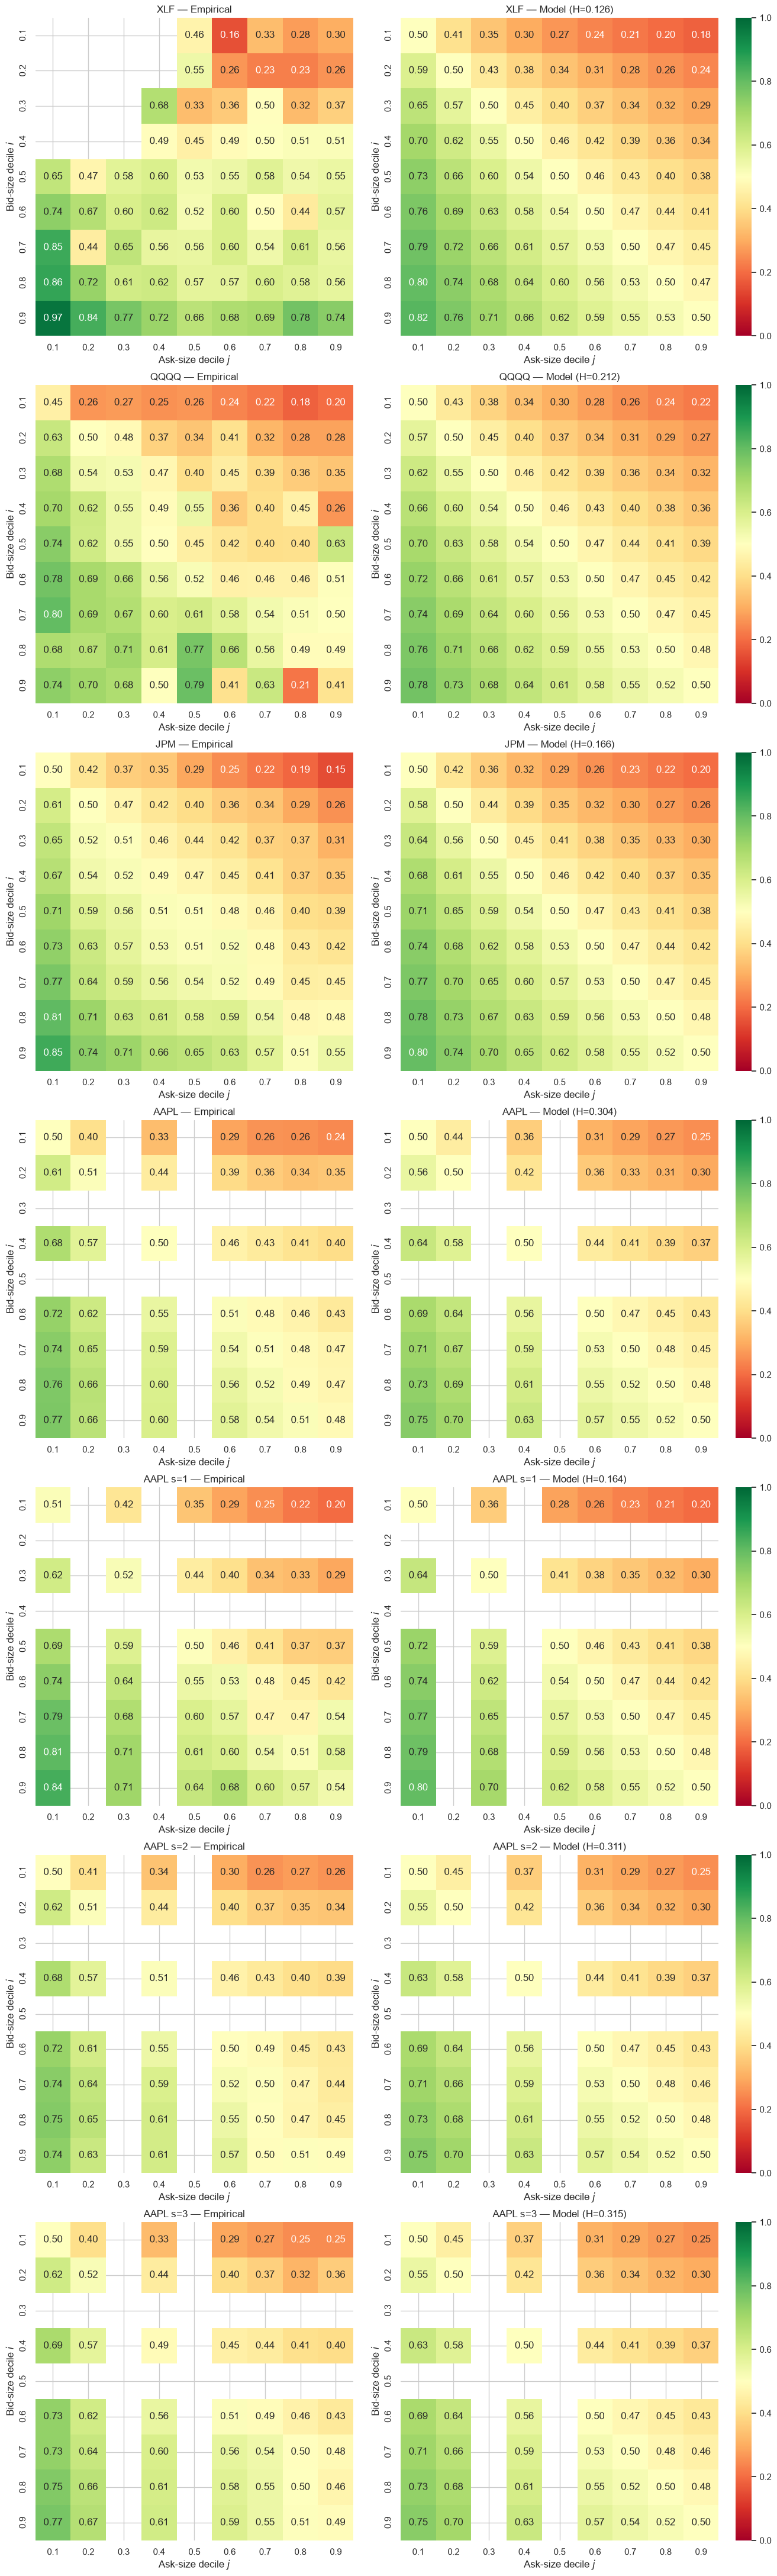

In [9]:
fig, axes = plt.subplots(len(results), 2, figsize=(13, 6.2 * len(results)), constrained_layout=True)
for row, (name, r) in enumerate(results.items()):
    for col, (title, matrix, mask) in enumerate([
        ("Empirical", r["empirical"], r["moves"] < MIN_MOVES),
        (f"Model (H={r['H']:.3f})", r["model"], r["counts"] == 0),
    ]):
        ax = axes[row, col]
        sns.heatmap(
            matrix.iloc[:9, :9], mask=mask.iloc[:9, :9], ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
            center=0.5, annot=True, fmt=".2f", cbar=col == 1, square=True,
        )
        ax.set_title(f"{name} — {title}")
        ax.set_xlabel("Ask-size decile $j$")
        ax.set_ylabel("Bid-size decile $i$")

figure_path = OUTPUT_DIR / "table3_empirical_vs_model_heatmaps.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

**Reading the tables.** In every case the probability of an up move rises with the bid-size decile (down the rows) and falls with the ask-size decile (across the columns). This is the order-imbalance effect: a thick bid relative to the ask signals that the ask queue is more likely to be depleted first. Even the extreme cells stay well inside $(0,1)$; for JPM, $p(0.9,0.1)=0.85$ and $p(0.1,0.9)=0.15$. The model attributes this to hidden liquidity $H$ behind both quotes.

**Why XLF (and the QQQQ corners) look noisy.** The XLF table rests on only 1,325 price moves. Cells in which both sizes are small (the masked top-left block) are resolved by a handful of moves each, so a single episode of several hundred quotes can push a cell to 0.99 or 0.92, as happened with separate cutoffs. Common cutoffs lower the weighted RMSE of XLF slightly (0.119 → 0.109), but the binding constraint is the number of price moves. JPM, with 29k moves, gives a smooth table and an RMSE of 0.038. The same mechanism explains isolated outliers in the rarely visited QQQQ corners, e.g. $(0.9, 0.8)$.

**Why the paper's table looks cleaner.** The paper's XLF table has exactly 0.50 on the diagonal and satisfies $p(i,j) = 1 - p(j,i)$, so it appears to be symmetrised: up-moves in $(i,j)$ are pooled with down-moves in $(j,i)$. We report the raw tables instead. With common cutoffs, symmetrising does not change $\hat H$. The model satisfies $p_{ji} = 1-p_{ij}$, so the symmetrised objective equals exactly twice the original one up to a constant, and both have the same minimiser.

### 3.4 Sensitivity of $H$ to conventions

Each column changes one convention relative to the baseline (common cutoffs, upper-bound labels, weights = quotes per cell).

In [10]:
robustness = pd.DataFrame([
    {
        "case": name,
        "baseline": r["H"],
        "unweighted": r["H_unweighted"],
        "midpoint labels": r["H_midpoint_labels"],
        "weights = moves per cell": r["H_move_weights"],
        "separate bid/ask cutoffs": r["H_separate_cutoffs"],
        "paper": PAPER_H_NASDAQ.get(name, np.nan),
    }
    for name, r in results.items()
]).set_index("case")
robustness.to_csv(OUTPUT_DIR / "table3_H_robustness.csv")
display(robustness.style.format("{:.3f}", na_rep="—"))

,baseline,unweighted,midpoint labels,weights = moves per cell,separate bid/ask cutoffs,paper
case,,,,,,
XLF,0.126,0.163,0.176,0.177,0.141,0.150
QQQQ,0.212,0.175,0.262,0.200,0.218,0.210
JPM,0.166,0.160,0.216,0.187,0.165,0.170
AAPL,0.304,0.319,0.354,0.287,0.304,—
AAPL s=1,0.164,0.132,0.214,0.177,0.168,0.160
AAPL s=2,0.311,0.325,0.361,0.298,0.311,0.310
AAPL s=3,0.315,0.321,0.365,0.295,0.315,0.310


- **Labels.** Labelling buckets by their midpoint instead of their upper bound raises $\hat H$ by exactly 0.05 in every case. This is an identity: the model is unchanged under $(i, j, H) \to (i-c,\, j-c,\, H+c)$. $H$ is therefore defined only relative to a labelling convention, and its reading as "a fraction of the maximum queue size" assumes the upper-bound labels used here. Our close match with Table 4 under these labels suggests the paper used them too.
- **Weights.** Dropping the count weights moves $\hat H$ by up to 0.04 (QQQQ: 0.212 → 0.175; XLF: 0.126 → 0.163). The unweighted fit gives sparse, noisy cells the same influence as dense ones. Weighting by the number of distinct price moves instead of quotes moves $\hat H$ by 0.01–0.05.
- **Cutoffs.** Separate bid/ask cutoffs matter only for XLF (0.126 → 0.141). Elsewhere the change is below 0.006.
- **What it means.** For XLF and QQQQ these shifts are within about one clustered standard error. For JPM and AAPL they exceed it: there the data are precise enough that the convention matters more than sampling error. Values of $H$ are therefore comparable across securities or with the paper only when the conventions are held fixed, as they are in the comparison with Table 4.

## 4. How these results could be used

The table below turns the extreme cells into money: the average signed size of the next midquote move (in cents), next to the half-spread that a liquidity taker pays.

In [11]:
avg_spread_t = table2.query("exchange == 'T'").set_index("ticker")["avg_spread"]
use_rows = []
for name, r in results.items():
    ticker = name.split()[0]
    spread_cents = int(name[-1]) if " s=" in name else 100 * avg_spread_t[ticker]
    use_rows.append({
        "case": name,
        "p(0.9, 0.1)": r["empirical"].loc["0.9", "0.1"],
        "E[next Δmid | 0.9, 0.1] (¢)": r["next_dmid_cents"].loc["0.9", "0.1"],
        "p(0.1, 0.9)": r["empirical"].loc["0.1", "0.9"],
        "E[next Δmid | 0.1, 0.9] (¢)": r["next_dmid_cents"].loc["0.1", "0.9"],
        "moves in (0.9, 0.1)": int(r["moves"].loc["0.9", "0.1"]),
        "half-spread (¢)": spread_cents / 2,
    })
use_table = pd.DataFrame(use_rows).set_index("case")
use_table.to_csv(OUTPUT_DIR / "signal_value_extreme_cells.csv")
display(use_table.style.format("{:.2f}", na_rep="—").format("{:,}", subset=["moves in (0.9, 0.1)"]))

,"p(0.9, 0.1)","E[next Δmid | 0.9, 0.1] (¢)","p(0.1, 0.9)","E[next Δmid | 0.1, 0.9] (¢)","moves in (0.9, 0.1)",half-spread (¢)
case,,,,,,
XLF,0.97,0.49,0.30,-0.20,171,0.51
QQQQ,0.74,0.24,0.20,-0.31,"1,252",0.52
JPM,0.85,0.35,0.15,-0.36,"2,061",0.56
AAPL,0.77,0.36,0.24,-0.31,"12,908",1.75
AAPL s=1,0.84,0.56,0.20,-0.46,"1,884",0.50
AAPL s=2,0.74,0.30,0.26,-0.28,"2,807",1.00
AAPL s=3,0.77,0.37,0.25,-0.29,"3,093",1.50


**How big is the signal?** For a one-tick stock like JPM the next midquote move is almost always half a tick, so the expected next move is about $(2p-1)\times\tfrac12$¢. In cell $(0.9, 0.1)$, $p = 0.85$ gives $+0.35$¢, which is what the data show (0.353¢). The half-spread is 0.56¢. A trader who buys at the ask on this signal pays 0.56¢ over the mid to capture 0.35¢, and loses money before fees. The same holds for XLF (0.49¢ vs. 0.51¢, measured on only 171 price moves) and for QQQQ. AAPL at $s=1$ is the exception. Its book is thin, so the next move is often larger than half a tick, and the expected move (0.56¢) exceeds the 0.50¢ half-spread. The margin is only 0.06¢, however, well below a typical 2010 taker fee of about 0.3¢ per share. The imbalance is therefore **not a stand-alone signal for market orders**. It is mainly useful for choosing *how* to trade:

1. **Passive vs. aggressive execution.** A buyer resting on the bid wants the price to come to them. When the book is ask-heavy ($p$ low), the next move is likely down, so staying in the queue is cheap and likely to be filled. When it is bid-heavy ($p$ high), the price is likely to move away. The resting order risks going unfilled and the buyer would have to chase, so crossing the spread (or improving the bid) becomes the better choice. The table gives the probabilities needed to compare the half-spread paid now with the expected cost of chasing later.
2. **Market making.** The imbalance says which side is about to be run over. With a heavy bid, a market maker should raise or pull the ask to avoid being adversely selected, and lean its quotes (and its inventory target) toward the expected move.
3. **Micro-price.** $\text{mid} + (2p(i,j)-1)\times\tfrac12\,\text{tick}$ is a better short-horizon fair value than the midpoint. It can be used to mark inventory or as the reference price of an execution algorithm. The fitted model supplies $p(i,j)$ with a single parameter, which is more robust than the raw table in sparsely populated cells (see XLF). $H$ controls how far the estimate is shrunk toward $\tfrac12$.
4. **Venue and regime.** $H$ differs across venues: in the paper, QQQQ sizes are far more informative on Arca ($H=0.04$) than on Nasdaq (0.21). A router should therefore read the imbalance on the venue where it carries most information. For AAPL the signal should only be used when the spread is one tick ($H = 0.16$ vs. 0.31 at wider spreads).

**Caveats.** Displayed depth can be cancelled, refreshed, or placed deliberately to mislead. The table predicts only the direction of the next move, not when it happens. The estimates come from one week in 2010 (and, for XLF, from about 1,300 price moves), so they need out-of-sample validation. A live rule would also need queue position, fees and rebates, inventory, and risk limits.

## 5. Submission checklist

- [x] Table 2 for all four securities and three venues, side by side with the published values.
- [x] Nasdaq empirical and model Table 3 for all four securities, plus AAPL conditional on the spread.
- [x] Bid and ask decile cutoffs (pooled and per side).
- [x] $H$ with clustered standard errors, compared with Table 4; sensitivity to conventions.
- [x] Discussion of how the results could be used.
- [x] Code executed from beginning to end.

Generated CSV tables and the heatmap figure are stored in `HW3/outputs/`. The WRDS data file (≈1 GB) stays outside the notebook; see the setup cell for where it is looked up.

**Homework 3, Part 2 (RIT Simulation)** is individual: Elias's write-up is Section 6 below; Alex's, Elouan's and Matthieu's are in `HW3/RIT/<name>/`.

## 6. Part 2 — RIT ALGO1 Algorithmic Arbitrage (Elias Roubache)

*Discussion Session 04, 10 September 2026. Individual analysis. Code: `RIT/Elias/algo1_bot/`; plotted data: `RIT/Elias/data/`.*

CRZY trades on two venues, `CRZY_M` and `CRZY_A`. Positions are netted across the two, orders are capped at 10,000 shares, the position limit is 25,000, and there are no fees. Sometimes the bid on one venue is above the ask on the other: buying the cheap side and selling the rich side locks in the difference, **if both legs fill**.

### 6a. Strategy going in

A simple arbitrage bot. It polls both books and, whenever $b^A > a^M$ (or $b^M > a^A$), buys on the cheap venue and sells on the rich one. A completed pair leaves a net position of zero, so the only limits are speed and the order rate. I had a market-making mode too, but kept it off: in the test session passive fills lost money right after execution.

**Size.** Each pair took all the quantity that was crossed at the moment of the signal, cut into 10,000-share orders. The leg with less displayed size was sent first, and the second leg was sized to what the first one filled. Any leftover position was hedged after 250 ms, and everything was flattened at the end of the case.

In [ ]:
RIT_DIR = Path("RIT/Elias/data")
RUN_LABEL = {"test": "Test session", "heat_acct1": "Heat, account 1", "heat_acct2": "Heat, account 2"}
RUN_COLOR = {"test": "#2a78d6", "heat_acct1": "#eb6834", "heat_acct2": "#1baf7a"}
runs = pd.read_csv(RIT_DIR / "runs_summary.csv").set_index("run")
heat = pd.read_csv(RIT_DIR / "timeline_heat_acct1.csv")

def tidy(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e5", lw=0.6)
    ax.set_axisbelow(True)

### 6b. What happened

The **test session** (10 orders/s, few competitors) went as planned: 81 completed pairs, about \$20,000. The **heat** (about 50 bots, 20 minutes) did not. Figure 6.1 shows account 1 during the heat.

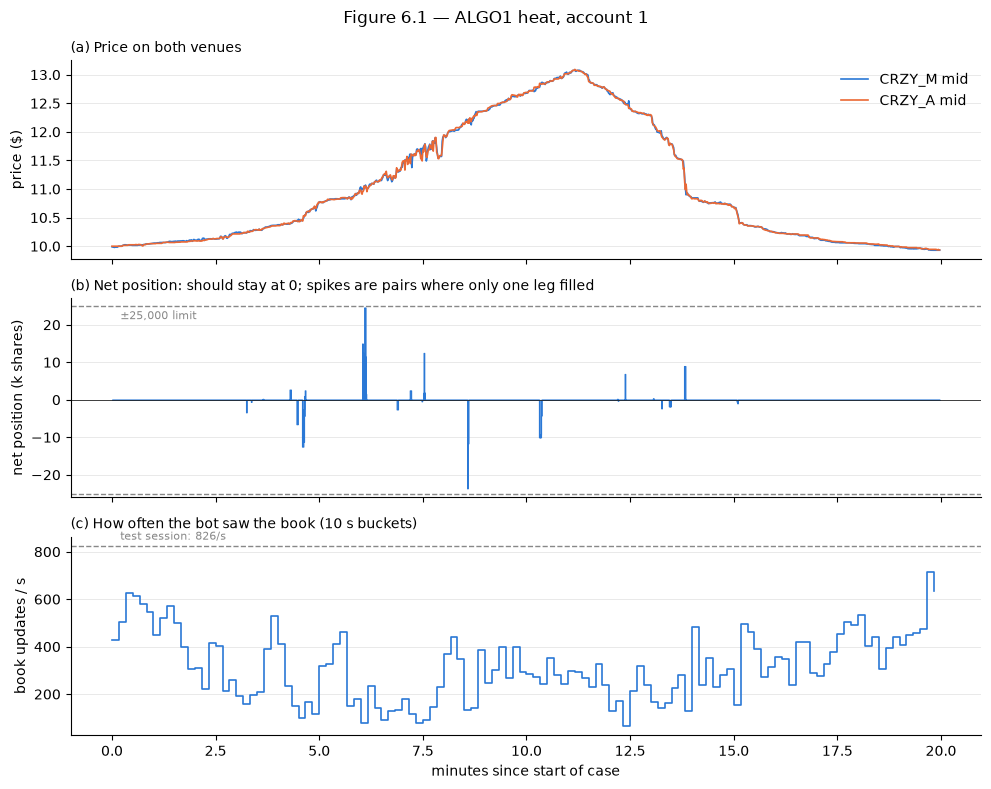

In [ ]:
# Figure 6.1: the heat on account 1
m = heat.t_s / 60
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(m, heat.mid_m, color="#2a78d6", lw=1.2, label="CRZY_M mid")
ax[0].plot(m, heat.mid_a, color="#eb6834", lw=1.2, label="CRZY_A mid")
ax[0].set_ylabel("price ($)"); ax[0].legend(frameon=False, loc="upper right")
ax[0].set_title("(a) Price on both venues", loc="left", fontsize=10)

ax[1].fill_between(m, heat.pos_min / 1e3, heat.pos_max / 1e3, color="#2a78d6", lw=0.8, step="post")
for y in (25, -25):
    ax[1].axhline(y, color="#888888", ls="--", lw=1)
ax[1].text(0.2, 21.5, "±25,000 limit", color="#888888", fontsize=8)
ax[1].axhline(0, color="#222222", lw=0.6)
ax[1].set_ylabel("net position (k shares)")
ax[1].set_title("(b) Net position: should stay at 0; spikes are pairs where only one leg filled", loc="left", fontsize=10)

r10 = heat.groupby(heat.t_s // 10).polls.sum() / 10
ax[2].step(r10.index * 10 / 60, r10.values, where="post", color="#2a78d6", lw=1.2)
ax[2].axhline(runs.loc["test", "polls_per_s"], color="#888888", ls="--", lw=1)
ax[2].text(0.2, runs.loc["test", "polls_per_s"] + 25, f"test session: {runs.loc['test', 'polls_per_s']:.0f}/s",
           color="#888888", fontsize=8)
ax[2].set_ylabel("book updates / s"); ax[2].set_xlabel("minutes since start of case")
ax[2].set_title("(c) How often the bot saw the book (10 s buckets)", loc="left", fontsize=10)
for a in ax:
    tidy(a)
fig.suptitle("Figure 6.1 — ALGO1 heat, account 1", fontsize=12)
plt.tight_layout(); plt.show()

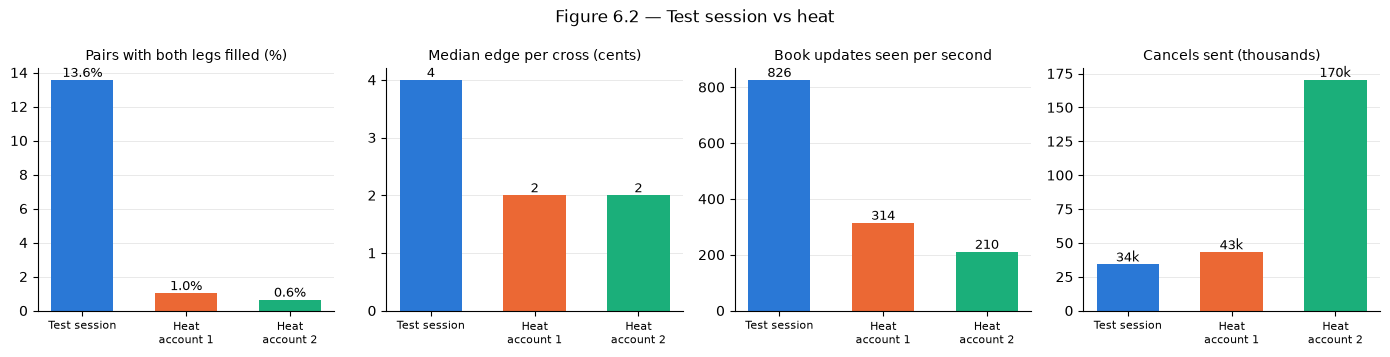

In [ ]:
# Figure 6.2: test session vs heat
metrics = [("completion_pct", "Pairs with both legs filled (%)", "{:.1f}%"),
           ("median_max_edge_ticks", "Median edge per cross (cents)", "{:.0f}"),
           ("polls_per_s", "Book updates seen per second", "{:.0f}"),
           ("cancels", "Cancels sent (thousands)", "{:.0f}k")]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for a, (col, title, fmt) in zip(axes, metrics):
    v = runs[col] / (1e3 if col == "cancels" else 1)
    bars = a.bar([RUN_LABEL[r].replace(", ", "\n") for r in v.index], v.values,
                 color=[RUN_COLOR[r] for r in v.index], width=0.6)
    for b, x in zip(bars, v.values):
        a.text(b.get_x() + b.get_width() / 2, x, fmt.format(x), ha="center", va="bottom", fontsize=9)
    a.set_title(title, fontsize=10); a.tick_params(axis="x", labelsize=8); tidy(a)
fig.suptitle("Figure 6.2 — Test session vs heat", fontsize=12)
plt.tight_layout(); plt.show()

Why the heat went worse:

1. **Competition.** With about 50 bots on the same crosses, the typical edge fell from 4 to 2 cents and the crossed shares were usually gone before my second leg arrived. Only 1 % of pairs filled on both legs, against 13.6 % in the test (Figure 6.2).
2. **One-leg fills.** Each missed second leg left an open position, up to 24,600 shares (Figure 6.1b). Hedging one of those a few cents away wipes out the profit of many 2-cent pairs.
3. **Too many cancels.** My second legs were LIMIT orders; when they missed they rested and had to be cancelled (43,000 on account 1, 170,000 on account 2). The RIT client handles one request at a time, so those cancels slowed my view of the market from 826 to 314 updates per second (Figure 6.1c). This made me even later to the next cross.

Running the same bot on both accounts also did not help: both accounts competed for the same crosses.

**After the heat** I switched both legs to MARKET orders sent at the same time (`configs/fast.json`): nothing rests, so there is nothing to cancel.

**How to use the script** (on the RIT machine, with the API enabled):

```
pip install -r requirements.txt
copy secrets.env.example secrets.env           # paste the API key and port from the RIT client
python -m algo1 run --name heat --params configs/fast.json
```

It trades until the case ends, then flattens. To stop it early, press Ctrl-C (it cancels open orders and flattens first).

### 6c. MARKET vs LIMIT orders

- **MARKET orders** always execute (if there is liquidity), but the price is not guaranteed. The risk is **slippage**: if the cross disappears before the order arrives, you trade at a worse price, and in a thin book you can walk several levels.
- **LIMIT orders** guarantee the price, but not execution. The risk is **not getting filled**: in an arbitrage, one leg fills and the other does not, leaving an open position (my main problem in the heat). A resting limit order can also be **picked off** when the price moves against it, and every unfilled order has to be cancelled.

For this arbitrage, MARKET orders are better: a small, bounded slippage cost is cheaper than an unhedged position. LIMIT orders make more sense for market making, where you want to earn the spread.

### 6d. P&L

| session | P&L |
|---|---|
| test session | ≈ +\$20,000 |
| **heat** | **+\$837** |

The heat was profitable but small: completed pairs made money and the one-leg positions gave part of it back. One lesson: the bot's own P&L estimate was wrong during the heat, because RIT reports positions with a delay. The figure to trust is the one in the RIT client.

## Appendix: full $10\times10$ tables used in the fit

For each case: empirical probability, model probability, number of quotes, and number of distinct price moves per cell. Unmasked, so that every number entering eq. (14) is visible.

In [12]:
for name, r in results.items():
    display(Markdown(f"#### {name}"))
    display(pd.concat(
        {"empirical": r["empirical"].round(2), "model": r["model"].round(2)}, axis=1
    ).style.format(precision=2, na_rep=""))
    display(pd.concat(
        {"quotes": r["counts"], "price moves": r["moves"]}, axis=1
    ).astype(int).style.format("{:,}"))

#### XLF

#### QQQQ

#### JPM

#### AAPL

#### AAPL s=1

#### AAPL s=2

#### AAPL s=3